# 03 - Demand Forecasting and Macro Scenarios

## Goal

Estimate customer offer-acceptance probability (`p_accept`) and stress it under macro scenarios (`base`, `stress`, `benign`).

Output: `data/df_demand.csv` for optimization notebook.

In [1]:
import sys, warnings
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

ROOT = Path().cwd().parent
sys.path.insert(0, str(ROOT / 'src'))

from demand_model import (
    SCENARIOS, build_proxy_dataset, fit_acceptance_model,
    score_scenarios, scenario_summary,
    plot_probability_distributions, plot_scenario_by_tier,
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

df = pd.read_csv(ROOT / 'data' / 'df_risk.csv')
print(f'Loaded: {df.shape}')

Loaded: (30000, 19)


---
## 1. Proxy Target Design

The source dataset has no explicit `offer_shown` / `offer_accepted` logs.

Proxy used:
- keep only `eligible == 1`
- treat `received` as `accepted_proxy`

This is a practical forecasting proxy, not causal truth.

In [2]:
model_df = build_proxy_dataset(df)
print(f'Modeling rows (eligible only): {len(model_df):,}')
print(f'Proxy acceptance rate: {model_df["accepted_proxy"].mean()*100:.2f}%')
model_df[['risk_label', 'accepted_proxy']].groupby('risk_label').mean().round(3)

Modeling rows (eligible only): 25,068
Proxy acceptance rate: 56.12%


,accepted_proxy
risk_label,
Near-Prime,0.559
Prime,0.562
Sub-Prime,0.565


---
## 2. Base Acceptance Model

Model: logistic regression on risk + loan + recency + utilization features.

Main quality metric: holdout ROC-AUC.

In [3]:
artifact = fit_acceptance_model(model_df, random_state=42)
print('Model metrics:')
print(f'  AUC      : {artifact["auc"]:.3f}')
print(f'  Base rate: {artifact["base_rate"]:.3f}')
print(f'  Train/Test: {artifact["n_train"]:,} / {artifact["n_test"]:,}')
print(f'  Mode: {artifact["mode"]}')
if artifact.get('weak_signal'):
    print('  Weak signal detected (AUC ~ random): switching to segment_fallback demand model')

Model metrics:
  AUC      : 0.493
  Base rate: 0.561
  Train/Test: 18,801 / 6,267


---
## 3. Macro Scenarios

Scenario assumptions from module:
- `base`: neutral
- `stress`: lower acceptance, stronger reduction for riskier tiers
- `benign`: higher acceptance, stronger uplift for riskier tiers

,segment,n,p_base,p_stress,p_benign
0,Near-Prime,15103,56.19,45.20,62.68
1,Prime,7520,56.03,49.55,60.28
2,Sub-Prime,7377,56.26,38.50,65.01
3,Total,30000,56.17,44.64,62.65


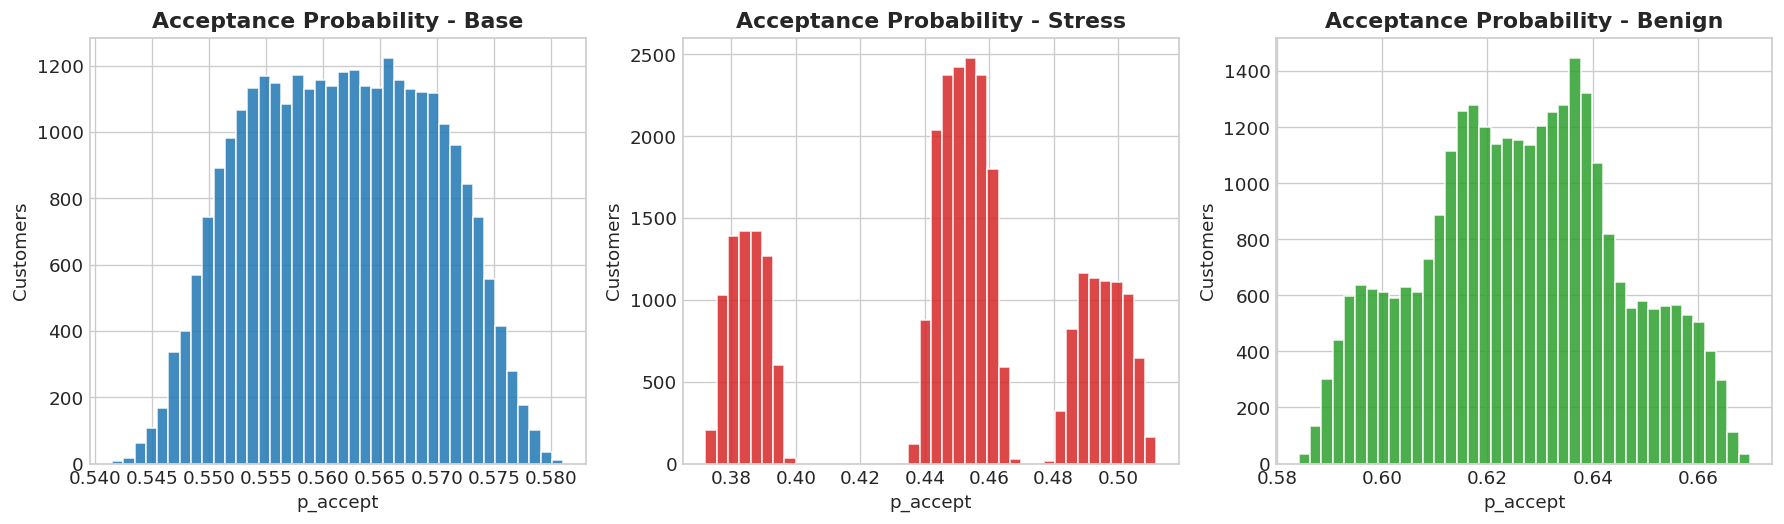

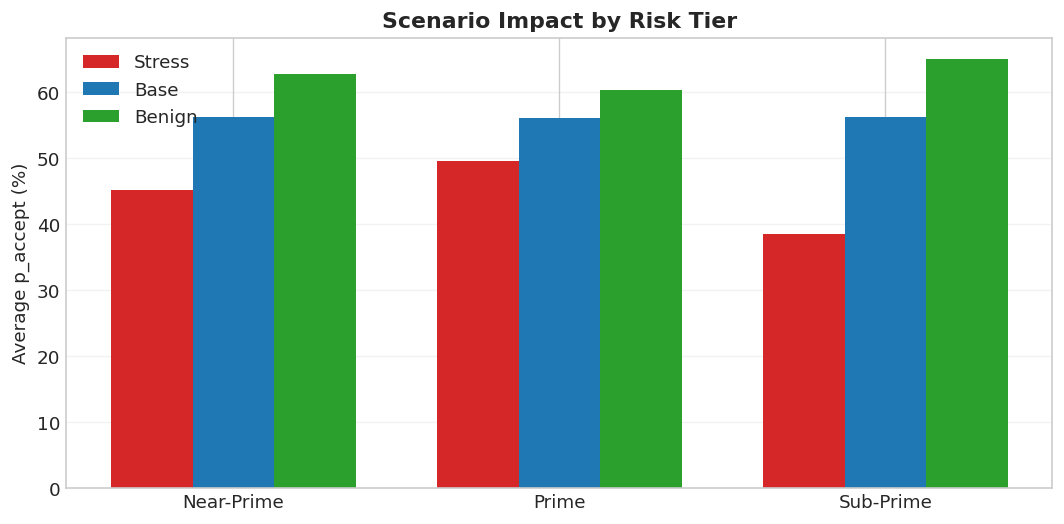

In [4]:
scored = score_scenarios(df, artifact)
summary = scenario_summary(scored)
display((summary.assign(
    p_base=lambda d: d['p_base']*100,
    p_stress=lambda d: d['p_stress']*100,
    p_benign=lambda d: d['p_benign']*100,
).round(2)))

plot_probability_distributions(scored)
plot_scenario_by_tier(summary)

---
## 4. Expected Accepted Offers

For one offer decision per customer, expected accepted count is:

`sum(p_accept_scenario)`

These values feed the optimization model in Notebook 04.

In [5]:
exp_stats = {
    'exp_accept_base': scored['exp_accept_base'].sum(),
    'exp_accept_stress': scored['exp_accept_stress'].sum(),
    'exp_accept_benign': scored['exp_accept_benign'].sum(),
}
for k, v in exp_stats.items():
    print(f'{k:<20}: {v:,.1f}')

exp_accept_base     : 16,850.1
exp_accept_stress   : 13,393.2
exp_accept_benign   : 18,795.6


---
## 5. Export

Save scored demand table for optimization and simulation notebooks.

In [6]:
out_cols = [
    'customer_id', 'risk_state', 'risk_label', 'eligible', 'received',
    'initial_loan', 'days_since_last_loan', 'on_time_pct',
    'pd_monthly', 'pd_annual', 'ev_per_increase',
    'p_accept_base', 'p_accept_stress', 'p_accept_benign',
    'exp_accept_base', 'exp_accept_stress', 'exp_accept_benign',
]
out = ROOT / 'data' / 'df_demand.csv'
scored[out_cols].to_csv(out, index=False)
print(f'Saved: {out}')
print(f'Shape: {scored[out_cols].shape}')

Saved: /data/aturov/loan_limit_increases/data/df_demand.csv
Shape: (30000, 17)
